# 03. Staggered Adoption and Modern DiD Issues

Many real rollouts are not clean two-group designs. A pricing policy may launch in one market in April, another in June, another in August, and never in some markets. A new operational workflow may be adopted by early, middle, and late regions. A compliance rule may turn on at different times because legal approval differs by country.

In a staggered adoption design, units adopt treatment at different dates, and treatment is usually absorbing once adopted. These designs look like natural extensions of the earlier DiD and event-study notebooks, but they create a subtle problem. Standard two-way fixed effects (TWFE) regressions can compare newly treated units to untreated units and to already treated units. When treatment effects are dynamic or heterogeneous, those already treated units are no longer clean controls.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain why staggered adoption is not just a larger version of 2x2 DiD.
- Identify the problem created when already treated units serve as controls.
- See how TWFE can place negative weight on some treated cohort-period effects.
- Distinguish a static TWFE estimate from a group-time ATT estimand.
- Estimate simple clean group-time DiD effects using not-yet-treated controls.
- Estimate an imputation-style DiD effect by modeling untreated potential outcomes.
- Recognize why conventional TWFE event-study leads can be misleading under heterogeneous effects.
- Build an industry readout that reports adoption cohorts, clean controls, and estimator choice.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def extract_parameter(model, parameter):
    """Extract one model parameter with its uncertainty and p-value.

    Args:
        model: Fitted model object whose parameters or predictions are being used.
        parameter: Model parameter name to extract from a fitted object.

    Returns:
        pandas.Series: Estimate, standard error, interval, and p-value for one parameter.
    """
    ci_low, ci_high = model.conf_int().loc[parameter]
    return pd.Series(
        {
            "estimate": model.params[parameter],
            "std_error": model.bse[parameter],
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": model.pvalues[parameter],
        }
    )


def event_term(event_time):
    """Convert an event-time value into the safe formula term used by statsmodels.

    Args:
        event_time: Time relative to treatment adoption or intervention.

    Returns:
        str: Formula-safe event-time coefficient name.
    """
    return f"event_m{abs(int(event_time))}" if event_time < 0 else f"event_p{int(event_time)}"

## 1. The Staggered Adoption Setup

Let $G_i$ be the first period in which unit $i$ becomes treated. Units that never adopt have $G_i = \infty$. Treatment status is:

$$
D_{it} = 1[t \ge G_i]
$$

The old two-way fixed effects regression is often written as:

$$
Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + \epsilon_{it}
$$

This looks harmless. Unit fixed effects remove stable unit differences. Time fixed effects remove common calendar shocks. The coefficient $\tau$ seems like an average treatment effect.

The modern DiD literature shows that this interpretation can fail when treatment timing varies and effects differ across cohorts or event time. Goodman-Bacon (2021) shows that TWFE with timing variation combines many 2x2 DiD comparisons. De Chaisemartin and D'Haultfoeuille (2020) show that TWFE can be a weighted sum of treatment effects with weights that may be negative. Sun and Abraham (2021) show related contamination problems in event-study regressions with heterogeneous effects.


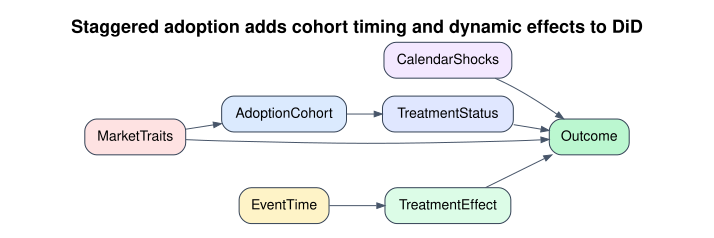

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("AdoptionCohort", "TreatmentStatus"),
        ("TreatmentStatus", "Outcome"),
        ("EventTime", "TreatmentEffect"),
        ("TreatmentEffect", "Outcome"),
        ("MarketTraits", "AdoptionCohort"),
        ("MarketTraits", "Outcome"),
        ("CalendarShocks", "Outcome"),
    ],
    title="Staggered adoption adds cohort timing and dynamic effects to DiD",
    node_colors={
        "AdoptionCohort": "#dbeafe",
        "TreatmentStatus": "#e0e7ff",
        "EventTime": "#fef3c7",
        "TreatmentEffect": "#dcfce7",
        "Outcome": "#bbf7d0",
        "MarketTraits": "#fee2e2",
        "CalendarShocks": "#f3e8ff",
    },
)


The graph has two key additions relative to the simple DiD notebook. First, treatment timing is itself a feature of the design. Second, treatment effects can depend on event time and cohort. Early adopters may get larger effects because they are more ready, or smaller effects because they are pilots still learning the workflow. Either way, effect heterogeneity matters.


## 2. Running Example: AI Support Workflow Across Markets

Suppose a company deploys an AI-assisted customer support workflow across regional markets. Early markets have stronger data infrastructure and higher operational readiness. Later markets adopt after integration work is finished. Some markets never adopt during the analysis window.

This is common in industry:

- Legal approval arrives at different dates across countries.
- Operations teams roll out a workflow in waves.
- Enterprise customers migrate to a new platform at different renewal dates.
- A ranking or pricing system turns on after local monitoring gates pass.

We will simulate a world where the causal effect is positive in every treated cohort-period cell, but the effect is larger for early adopters and grows with time since adoption.


**Dataset and experiment setup.** The staggered-adoption dataset represents markets adopting an AI support workflow in different calendar periods. Each market is observed repeatedly, and some markets adopt early while others adopt later or remain not-yet-treated for part of the panel. Treatment effects vary by cohort and event time, which is realistic for operational rollouts where learning, staffing, and customer mix differ across launches. The simulation stores the true group-time effects so the notebook can show why familiar TWFE estimates can become contaminated when already-treated units are used as comparisons.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def treatment_effect_path(event_time, cohort):
    """
    Return the cohort-specific treatment effect for a staggered-adoption simulation.
    
    Idea:
        The path creates heterogeneous effects by cohort and exposure length, which helps explain why two-way fixed effects can become misleading.
    
    Args:
        event_time: Time measured relative to treatment adoption or rollout.
        cohort: Adoption cohort whose heterogeneous treatment path is being evaluated.
    
    Returns:
        float: True treatment effect for the requested cohort and event time.
    """
    if event_time < 0 or not np.isfinite(cohort):
        return 0.0

    mature_effect = {
        4: 9.5,
        6: 6.2,
        8: 4.2,
        10: 2.8,
    }[int(cohort)]
    ramp = {
        0: 0.18,
        1: 0.42,
        2: 0.68,
        3: 0.86,
    }.get(int(event_time), 1.0)
    return mature_effect * ramp


def simulate_staggered_rollout(n_markets=260, months=range(0, 15), seed=4303):
    """Generate staggered market adoption with heterogeneous dynamic effects.

    Args:
        n_markets: Number of markets generated in the simulation.
        months: Sequence of time periods used in the panel or time-series simulation.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)
    cohorts = np.array([4, 6, 8, 10, np.inf])
    cohort_probs = np.array([0.20, 0.22, 0.22, 0.18, 0.18])

    markets = pd.DataFrame({"market_id": np.arange(n_markets)})
    markets["cohort"] = rng.choice(cohorts, size=n_markets, p=cohort_probs)
    markets["cohort_label"] = markets["cohort"].replace({np.inf: "Never"}).astype(str)
    markets["market_size"] = rng.lognormal(
        mean=3.3 + np.where(markets["cohort"].eq(4), 0.18, 0.0),
        sigma=0.35,
        size=n_markets,
    )
    markets["baseline_ai_readiness"] = rng.normal(0, 1, n_markets) + np.select(
        [
            markets["cohort"].eq(4),
            markets["cohort"].eq(6),
            markets["cohort"].eq(8),
            markets["cohort"].eq(10),
        ],
        [0.80, 0.40, 0.15, -0.05],
        default=0.0,
    )
    markets["unit_fe"] = (
        55
        + 0.22 * markets["market_size"]
        + 3.50 * markets["baseline_ai_readiness"]
        + rng.normal(0, 4.0, n_markets)
    )

    rows = []
    for _, market in markets.iterrows():
        eps_prev = rng.normal(0, 2.0)
        for month in months:
            treated = int(np.isfinite(market["cohort"]) and month >= market["cohort"])
            event_time = month - market["cohort"] if np.isfinite(market["cohort"]) else np.nan
            common_time = 0.45 * month + 1.40 * np.sin((month + 1) / 2.2)
            eps = 0.50 * eps_prev + rng.normal(0, 2.3)
            eps_prev = eps

            effect = treatment_effect_path(event_time, market["cohort"]) if treated else 0.0
            untreated_outcome = market["unit_fe"] + common_time + 0.10 * month + rng.normal(0, 0.6) + eps
            observed_outcome = untreated_outcome + effect

            rows.append(
                {
                    "market_id": int(market["market_id"]),
                    "month": int(month),
                    "cohort": market["cohort"],
                    "cohort_label": "Never" if not np.isfinite(market["cohort"]) else str(int(market["cohort"])),
                    "treated": treated,
                    "event_time": event_time,
                    "revenue": observed_outcome,
                    "untreated_revenue": untreated_outcome,
                    "true_effect": effect,
                    "baseline_ai_readiness": market["baseline_ai_readiness"],
                }
            )

    return pd.DataFrame(rows)


df = simulate_staggered_rollout()
true_att = df.loc[df["treated"].eq(1), "true_effect"].mean()

rollout_summary = pd.Series(
    {
        "markets": df["market_id"].nunique(),
        "months": df["month"].nunique(),
        "rows": len(df),
        "ever_treated_market_share": df.drop_duplicates("market_id")["cohort"].pipe(np.isfinite).mean(),
        "true_ATT_over_treated_observations": true_att,
    }
).to_frame("value")
smart_display(rollout_summary)

,value
markets,260.000
months,15.000
rows,3900.000
ever_treated_market_share,0.796
true_ATT_over_treated_observations,5.083


In Running Example: AI Support Workflow Across Markets, the table is also evidence about the trend assumption. If the pre-period comparison is weak, the treatment effect should be read cautiously.

In [5]:
cohort_counts = (
    df.drop_duplicates("market_id")
    .groupby("cohort_label", observed=True)
    .agg(markets=("market_id", "nunique"), avg_readiness=("baseline_ai_readiness", "mean"))
    .reindex(["4", "6", "8", "10", "Never"])
)
smart_display(cohort_counts)


,markets,avg_readiness
cohort_label,,
4,49,0.814
6,64,0.558
8,54,0.452
10,40,-0.214
Never,53,-0.031


Early adopters have higher readiness. That is realistic: firms often start with teams that are operationally prepared. Unit fixed effects can absorb stable readiness differences, but heterogeneous effect sizes remain important because early cohorts also benefit more from the workflow.


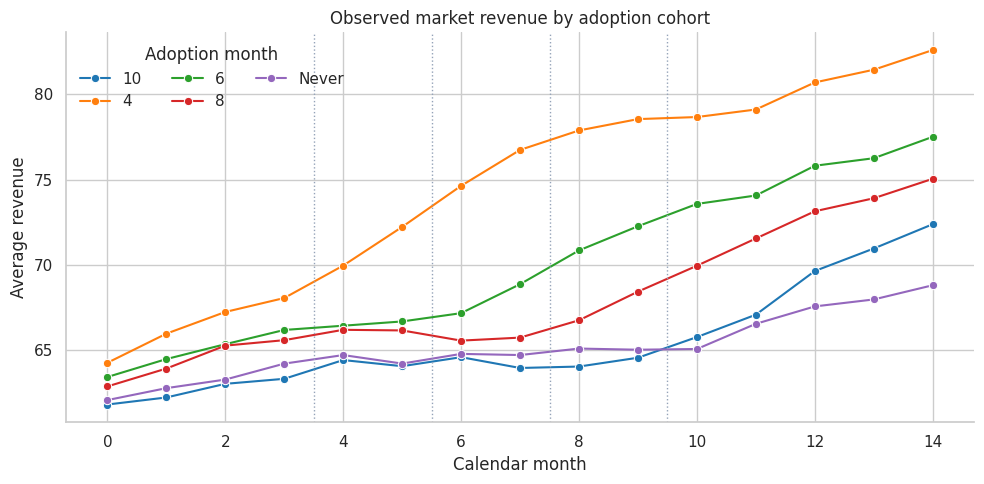

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
cohort_trends = (
    df.groupby(["cohort_label", "month"], observed=True)["revenue"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.0))
sns.lineplot(
    data=cohort_trends,
    x="month",
    y="revenue",
    hue="cohort_label",
    marker="o",
    palette="tab10",
    ax=ax,
)
for rollout_month in [4, 6, 8, 10]:
    ax.axvline(rollout_month - 0.5, color="#94a3b8", linestyle=":", linewidth=1)
ax.set_title("Observed market revenue by adoption cohort")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Average revenue")
ax.legend(title="Adoption month", frameon=False, ncol=3)
sns.despine(ax=ax)
plt.tight_layout()


The lines do not all turn on at the same time. That staggered timing is exactly what creates the modern DiD issue. In month 9, for example, cohorts 4, 6, and 8 are already treated, cohort 10 is not yet treated, and the never-treated cohort remains untreated. Which groups should count as controls depends on the estimand.


## 3. The True Effect Surface

Because this is a simulation, we can inspect the true cohort-by-event-time effect. In real data we never see this table; we estimate it.


In [7]:
# Assemble the true effect-surface table used for interpretation.
true_surface = (
    df[df["treated"].eq(1)]
    .groupby(["cohort", "event_time"], observed=True)
    .agg(true_effect=("true_effect", "mean"), observations=("market_id", "size"))
    .reset_index()
)

surface_pivot = true_surface.pivot(index="cohort", columns="event_time", values="true_effect")
smart_display(surface_pivot)


event_time,0.000,1.000,2.000,3.000,4.000,5.000,6.000,7.000,8.000,9.000,10.000
cohort,,,,,,,,,,,
4.000,1.710,3.990,6.460,8.170,9.500,9.500,9.500,9.500,9.500,9.500,9.500
6.000,1.116,2.604,4.216,5.332,6.200,6.200,6.200,6.200,6.200,NaN,NaN
8.000,0.756,1.764,2.856,3.612,4.200,4.200,4.200,NaN,NaN,NaN,NaN
10.000,0.504,1.176,1.904,2.408,2.800,NaN,NaN,NaN,NaN,NaN,NaN


In The True Effect Surface, the table is also evidence about the trend assumption. The design claim lives in the pre-period comparison as much as in the coefficient.

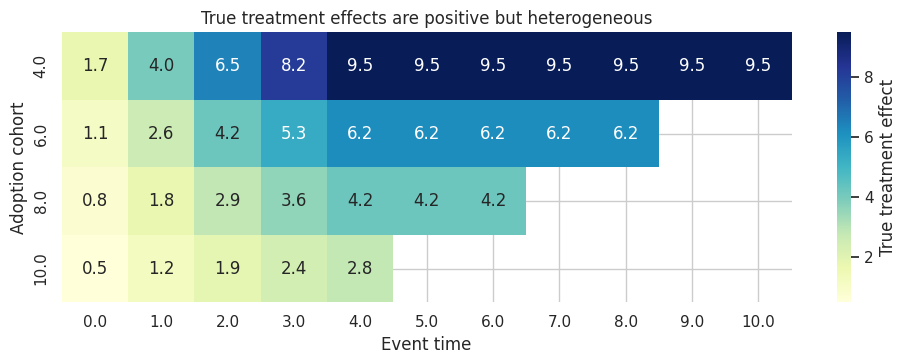

In [8]:
# Build the true effect-surface plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(
    surface_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "True treatment effect"},
    ax=ax,
)
ax.set_title("True treatment effects are positive but heterogeneous")
ax.set_xlabel("Event time")
ax.set_ylabel("Adoption cohort")
plt.tight_layout()


Every treated cell has a positive causal effect. The effect is larger for early cohorts and grows over event time. This is exactly the kind of heterogeneity that makes a single TWFE coefficient hard to interpret.


## 4. Static TWFE: The Familiar but Risky Estimate

Start with the old static TWFE regression:

$$
Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + \epsilon_{it}
$$

If effects were constant across cohorts and event time, $\tau$ would be easier to interpret. Here effects are not constant.


In [9]:
# Fit the Static TWFE: The Familiar but Risky Estimate model and collect the estimate needed below.
twfe_model = smf.ols("revenue ~ treated + C(market_id) + C(month)", data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["market_id"]},
)

twfe_row = extract_parameter(twfe_model, "treated").to_frame("static_TWFE").T
twfe_row["true_ATT_over_treated_observations"] = true_att
twfe_row["bias_vs_true_ATT"] = twfe_row["estimate"] - twfe_row["true_ATT_over_treated_observations"]
smart_display(twfe_row)


,estimate,std_error,ci_low,ci_high,p_value,true_ATT_over_treated_observations,bias_vs_true_ATT
static_TWFE,2.957,0.275,2.419,3.495,0.000,5.083,-2.126


The TWFE estimate is much smaller than the true average effect over treated observations. The gap appears because the regression is using a complicated weighted average of cohort-period effects, and some of those weights can be negative.


## 5. Diagnosing TWFE Weights

A useful diagnostic is to residualize the treatment indicator after removing unit and time fixed effects. The static TWFE coefficient can be written in terms of this residualized treatment variation. For treated cells, the contribution of a cohort-period effect is proportional to residualized treatment in that cell.

If residualized treatment is negative for a treated cell, that cell receives negative weight. De Chaisemartin and D'Haultfoeuille (2020) show why such negative weights can make a TWFE coefficient move away from any intuitive average treatment effect.


In [10]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def add_residualized_treatment(frame):
    """Residualize treatment on unit and time effects to diagnose TWFE weighting.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.

    Returns:
        pandas.DataFrame: Frame with residualized treatment values added.
    """
    work = frame.copy()
    overall_mean = work["treated"].mean()
    unit_mean = work.groupby("market_id")["treated"].transform("mean")
    time_mean = work.groupby("month")["treated"].transform("mean")
    work["treated_residualized"] = work["treated"] - unit_mean - time_mean + overall_mean
    return work


weight_frame = add_residualized_treatment(df)
denom = (weight_frame["treated_residualized"] ** 2).sum()

cell_weights = (
    weight_frame[weight_frame["treated"].eq(1)]
    .groupby(["cohort", "month", "event_time"], observed=True)
    .agg(
        weight=("treated_residualized", lambda x: x.sum() / denom),
        true_effect=("true_effect", "mean"),
        observations=("market_id", "size"),
    )
    .reset_index()
)

weight_summary = pd.Series(
    {
        "sum_of_treated_cell_weights": cell_weights["weight"].sum(),
        "number_of_negative_weight_cells": (cell_weights["weight"] < 0).sum(),
        "most_negative_weight": cell_weights["weight"].min(),
        "weighted_true_effect_using_TWFE_weights": (cell_weights["weight"] * cell_weights["true_effect"]).sum(),
        "simple_true_ATT": true_att,
    }
).to_frame("value")
smart_display(weight_summary)

,value
sum_of_treated_cell_weights,1.000
number_of_negative_weight_cells,5.000
most_negative_weight,-0.016
weighted_true_effect_using_TWFE_weights,2.707
simple_true_ATT,5.083


In Diagnosing TWFE Weights, the table is also evidence about the trend assumption. A convincing pre-period pattern is what lets the post-period gap carry causal weight.

In [11]:
negative_weight_cells = cell_weights.sort_values("weight").head(10)
negative_weight_cells[["cohort", "month", "event_time", "weight", "true_effect", "observations"]]


,cohort,month,event_time,weight,true_effect,observations
6,4.000,10,6.000,-0.016,9.500,49
7,4.000,11,7.000,-0.016,9.500,49
9,4.000,13,9.000,-0.016,9.500,49
8,4.000,12,8.000,-0.016,9.500,49
10,4.000,14,10.000,-0.016,9.500,49
15,6.000,10,4.000,0.008,6.200,64
17,6.000,12,6.000,0.008,6.200,64
16,6.000,11,5.000,0.008,6.200,64
19,6.000,14,8.000,0.008,6.200,64
18,6.000,13,7.000,0.008,6.200,64


This result supports the section on Diagnosing TWFE Weights. It is evidence about the trend assumption as much as the treatment effect. The estimate is credible only if the pre-period patterns make the untreated counterfactual believable.

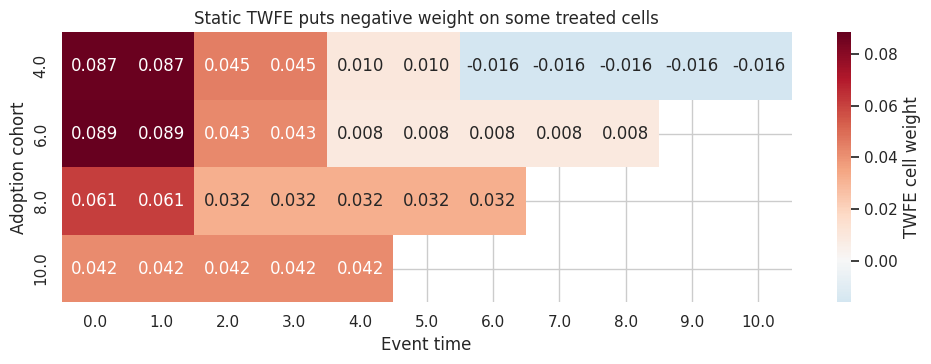

In [12]:
# Build the Diagnosing TWFE Weights plot from the quantities computed above.
weight_pivot = cell_weights.pivot(index="cohort", columns="event_time", values="weight")

fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(
    weight_pivot,
    annot=True,
    fmt=".3f",
    center=0,
    cmap="RdBu_r",
    cbar_kws={"label": "TWFE cell weight"},
    ax=ax,
)
ax.set_title("Static TWFE puts negative weight on some treated cells")
ax.set_xlabel("Event time")
ax.set_ylabel("Adoption cohort")
plt.tight_layout()


The late post-treatment periods for early adopters receive negative weight. Intuitively, by the time late cohorts adopt, early cohorts are already treated. The regression can use already treated cohorts as comparison groups for newly treated cohorts. If early cohorts have large mature effects, subtracting them can pull the TWFE coefficient downward.

This is the practical warning: in staggered adoption designs, "treated" is not a single clean comparison. The control group changes over time, and sometimes it is not clean.


## 6. Conventional TWFE Event Studies Can Also Be Contaminated

A common response is to estimate an event-study regression with leads and lags:

$$
Y_{it} = \alpha_i + \lambda_t + \sum_{k \ne -1} \beta_k 1[t - G_i = k] + \epsilon_{it}
$$

In a single adoption cohort, this is often a useful dynamic DiD display. With staggered adoption and heterogeneous effects, the conventional TWFE event-study coefficients can mix effects across cohorts and event times. Sun and Abraham (2021) show that the leads and lags from fixed-effect event-study regressions need not estimate clean dynamic effects under heterogeneous treatment effects.


In [13]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def add_event_indicators(frame, low=-5, high=8, reference=-1):
    """Add event-time indicators for staggered-adoption event-study models.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.
        reference: Reference value or omitted event time used for interpretation.

    Returns:
        pandas.DataFrame: Frame with staggered-adoption event indicators.
    """
    work = frame.copy()
    event_columns = []
    for event_time in range(low, high + 1):
        if event_time == reference:
            continue
        column = event_term(event_time)
        work[column] = (
            np.isfinite(work["cohort"]) & work["event_time"].eq(event_time)
        ).astype(int)
        event_columns.append(column)
    return work, event_columns


def fit_twfe_event_study(frame, low=-5, high=8, reference=-1):
    """Fit the conventional TWFE event-study specification.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.
        reference: Reference value or omitted event time used for interpretation.

    Returns:
        tuple: Fitted TWFE event-study model and coefficient table.
    """
    work, event_columns = add_event_indicators(frame, low=low, high=high, reference=reference)
    formula = "revenue ~ " + " + ".join(event_columns) + " + C(market_id) + C(month)"
    model = smf.ols(formula, data=work).fit(
        cov_type="cluster",
        cov_kwds={"groups": work["market_id"]},
    )

    rows = []
    for event_time in range(low, high + 1):
        if event_time == reference:
            rows.append({"event_time": event_time, "estimate": 0.0, "ci_low": 0.0, "ci_high": 0.0})
            continue
        column = event_term(event_time)
        ci_low, ci_high = model.conf_int().loc[column]
        rows.append(
            {
                "event_time": event_time,
                "estimate": model.params[column],
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )
    return model, pd.DataFrame(rows), event_columns


twfe_event_model, twfe_event_table, event_columns = fit_twfe_event_study(df)
twfe_event_table.head(10)

,event_time,estimate,ci_low,ci_high
0,-5,-0.201,-0.673,0.272
1,-4,-2.096,-2.630,-1.563
2,-3,-1.333,-1.841,-0.825
3,-2,-2.905,-3.522,-2.287
4,-1,0.000,0.000,0.000
5,0,-2.376,-3.053,-1.698
6,1,0.083,-0.441,0.607
7,2,0.606,-0.120,1.332
8,3,2.506,1.913,3.099
9,4,2.445,1.710,3.181


In Conventional TWFE Event Studies Can Also Be Contaminated, the model output is also evidence about the trend assumption. Pre-period behavior is what makes the untreated counterfactual believable.

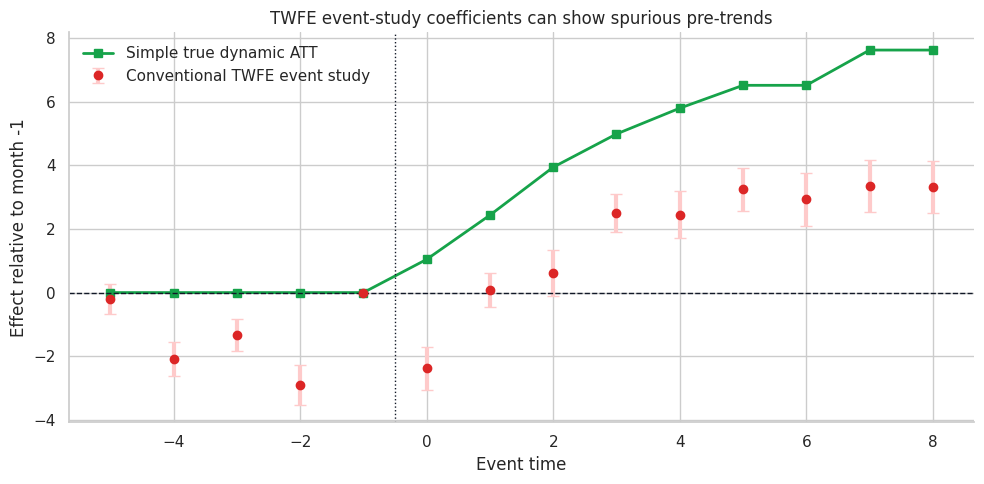

In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def clean_event_time_truth(frame):
    """Compute the clean average true effect by event time.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.

    Returns:
        pandas.DataFrame: True average effect by event time.
    """
    return (
        frame[frame["treated"].eq(1)]
        .groupby("event_time", observed=True)
        .agg(true_effect=("true_effect", "mean"))
        .reset_index()
    )

true_dynamic = clean_event_time_truth(df)
plot_twfe_event = twfe_event_table.merge(true_dynamic, on="event_time", how="left")
plot_twfe_event["true_effect"] = plot_twfe_event["true_effect"].fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 5.0))
ax.errorbar(
    plot_twfe_event["event_time"],
    plot_twfe_event["estimate"],
    yerr=[plot_twfe_event["estimate"] - plot_twfe_event["ci_low"], plot_twfe_event["ci_high"] - plot_twfe_event["estimate"]],
    fmt="o",
    color="#dc2626",
    ecolor="#fecaca",
    elinewidth=3,
    capsize=4,
    label="Conventional TWFE event study",
)
ax.plot(
    plot_twfe_event["event_time"],
    plot_twfe_event["true_effect"],
    color="#16a34a",
    marker="s",
    linewidth=2,
    label="Simple true dynamic ATT",
)
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(-0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("TWFE event-study coefficients can show spurious pre-trends")
ax.set_xlabel("Event time")
ax.set_ylabel("Effect relative to month -1")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()

The simulation has no anticipation: true pre-treatment effects are exactly zero. Yet the conventional TWFE event-study leads are not close to zero. That is not evidence of real pre-treatment behavior in this simulation. It is a contamination artifact created by staggered timing and heterogeneous post-treatment effects.

This is one of the most important modern DiD lessons: in staggered adoption settings, a TWFE event-study pre-trend plot can fail as a diagnostic because the lead coefficients themselves can be contaminated by treatment-effect heterogeneity.


## 7. Clean Group-Time ATT with Not-Yet-Treated Controls

A cleaner target is the group-time average treatment effect:

$$
ATT(g,t) = E[Y_t(1) - Y_t(0) \mid G = g]
$$

for cohort $g$ in time $t \ge g$. A simple no-covariate estimator compares cohort $g$ to units that have not yet adopted by time $t$ or never adopt. The baseline is the period just before cohort $g$ adopts, $g-1$:

$$
\widehat{ATT}(g,t) =
(\bar{Y}_{g,t} - \bar{Y}_{g,g-1})
-
(\bar{Y}_{C(g,t),t} - \bar{Y}_{C(g,t),g-1})
$$

where $C(g,t)$ contains not-yet-treated or never-treated units at time $t$. This is the intuition behind group-time ATT approaches such as Callaway and Sant'Anna (2021), though full implementations can add covariates, doubly robust scores, and formal inference.


In [15]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def estimate_group_time_att(frame):
    """Estimate group-time ATT values using not-yet-treated controls.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.

    Returns:
        pandas.DataFrame: Group-time ATT estimates.
    """
    rows = []
    cohorts = sorted(cohort for cohort in frame["cohort"].unique() if np.isfinite(cohort))
    months = sorted(frame["month"].unique())

    for cohort in cohorts:
        baseline = int(cohort - 1)
        for month in months:
            if month < int(cohort):
                continue

            treated_mask = frame["cohort"].eq(cohort)
            control_mask = frame["cohort"].gt(month) | ~np.isfinite(frame["cohort"])

            treated_two_periods = frame[treated_mask & frame["month"].isin([baseline, month])]
            control_two_periods = frame[control_mask & frame["month"].isin([baseline, month])]

            if treated_two_periods["market_id"].nunique() == 0 or control_two_periods["market_id"].nunique() == 0:
                continue

            treated_means = treated_two_periods.groupby("month")["revenue"].mean()
            control_means = control_two_periods.groupby("month")["revenue"].mean()
            if not {baseline, month}.issubset(treated_means.index) or not {baseline, month}.issubset(control_means.index):
                continue

            att = (treated_means.loc[month] - treated_means.loc[baseline]) - (
                control_means.loc[month] - control_means.loc[baseline]
            )
            true_cell_att = frame[treated_mask & frame["month"].eq(month)]["true_effect"].mean()
            n_treated = frame[treated_mask & frame["month"].eq(month)].shape[0]
            rows.append(
                {
                    "cohort": cohort,
                    "month": month,
                    "event_time": month - cohort,
                    "att_hat": att,
                    "true_att": true_cell_att,
                    "treated_observations": n_treated,
                    "control_markets": control_two_periods["market_id"].nunique(),
                }
            )

    return pd.DataFrame(rows)


group_time_att = estimate_group_time_att(df)
group_time_att.head(10)

,cohort,month,event_time,att_hat,true_att,treated_observations,control_markets
0,4.000,4,0.000,1.336,1.710,49,211
1,4.000,5,1.000,3.729,3.990,49,211
2,4.000,6,2.000,6.033,6.460,49,147
3,4.000,7,3.000,8.270,8.170,49,147
4,4.000,8,4.000,9.007,9.500,49,93
5,4.000,9,5.000,9.488,9.500,49,93
6,4.000,10,6.000,9.748,9.500,49,53
7,4.000,11,7.000,8.713,9.500,49,53
8,4.000,12,8.000,9.279,9.500,49,53
9,4.000,13,9.000,9.616,9.500,49,53


In Clean Group-Time ATT with Not-Yet-Treated Controls, the table is also evidence about the trend assumption. If the pre-period comparison is weak, the treatment effect should be read cautiously.

In [16]:
# Assemble the Clean Group-Time ATT with Not-Yet-Treated Controls summary table used for interpretation.
clean_static_att = np.average(group_time_att["att_hat"], weights=group_time_att["treated_observations"])
clean_true_att = np.average(group_time_att["true_att"], weights=group_time_att["treated_observations"])

clean_summary = pd.Series(
    {
        "clean_group_time_ATT": clean_static_att,
        "true_ATT_over_same_cells": clean_true_att,
        "static_TWFE_estimate": twfe_model.params["treated"],
    }
).to_frame("value")
smart_display(clean_summary)


,value
clean_group_time_ATT,5.080
true_ATT_over_same_cells,5.083
static_TWFE_estimate,2.957


In Clean Group-Time ATT with Not-Yet-Treated Controls, judge the output by the design claim that stands in for randomization. The causal work comes from the assignment rule, timing, threshold, instrument, or comparison series.

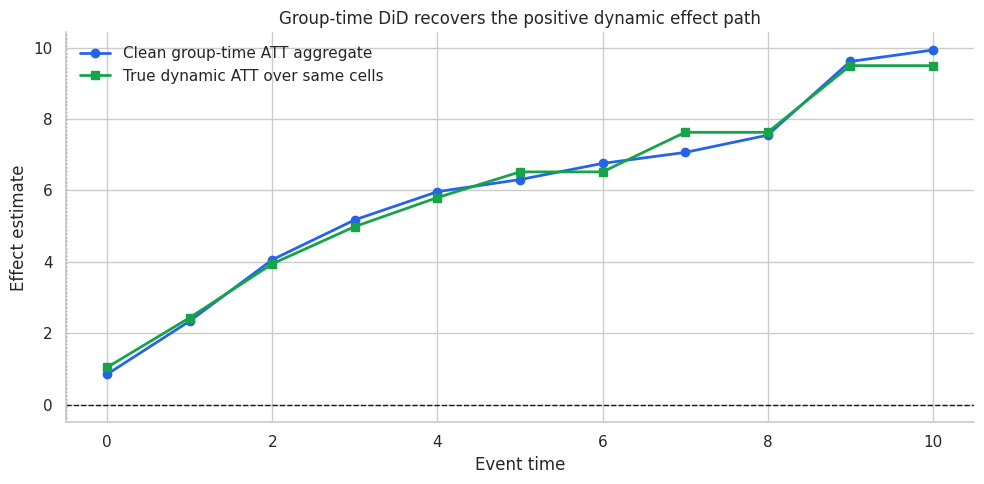

In [17]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
clean_dynamic = (
    group_time_att.groupby("event_time", observed=True)
    .apply(
        lambda g: pd.Series(
            {
                "att_hat": np.average(g["att_hat"], weights=g["treated_observations"]),
                "true_att": np.average(g["true_att"], weights=g["treated_observations"]),
                "treated_observations": g["treated_observations"].sum(),
            }
        )
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(
    clean_dynamic["event_time"],
    clean_dynamic["att_hat"],
    marker="o",
    linewidth=2,
    color="#2563eb",
    label="Clean group-time ATT aggregate",
)
ax.plot(
    clean_dynamic["event_time"],
    clean_dynamic["true_att"],
    marker="s",
    linewidth=2,
    color="#16a34a",
    label="True dynamic ATT over same cells",
)
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(-0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Group-time DiD recovers the positive dynamic effect path")
ax.set_xlabel("Event time")
ax.set_ylabel("Effect estimate")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The clean group-time estimator uses not-yet-treated and never-treated markets as controls. It does not use already treated markets as controls for newly treated markets. The resulting dynamic path is much closer to the true effect surface.


## 8. Imputation-Style DiD

Another modern approach estimates the untreated potential outcome model using only untreated observations, then imputes what treated observations would have looked like without treatment. The idea is:

1. Fit an outcome model on observations with $D_{it}=0$.
2. Predict $\hat{Y}_{it}(0)$ for treated observations.
3. Estimate $\hat{\tau}_{it} = Y_{it} - \hat{Y}_{it}(0)$.
4. Aggregate the treatment-effect estimates over the target cells.

Borusyak, Jaravel, and Spiess (2024) develop a robust and efficient event-study framework based on this kind of imputation logic. Here we implement the simplest fixed-effect version for teaching.


In [18]:
# Assemble the Imputation-Style DiD summary table used for interpretation.
untreated_rows = df[df["treated"].eq(0)].copy()
imputation_model = smf.ols("revenue ~ C(market_id) + C(month)", data=untreated_rows).fit()

df_imputed = df.copy()
df_imputed["y0_hat"] = imputation_model.predict(df_imputed)
df_imputed["tau_hat_imputation"] = df_imputed["revenue"] - df_imputed["y0_hat"]

imputation_static_att = df_imputed.loc[df_imputed["treated"].eq(1), "tau_hat_imputation"].mean()
imputation_summary = pd.Series(
    {
        "imputation_ATT": imputation_static_att,
        "true_ATT_over_treated_observations": true_att,
        "static_TWFE_estimate": twfe_model.params["treated"],
        "clean_group_time_ATT": clean_static_att,
    }
).to_frame("value")
smart_display(imputation_summary)


,value
imputation_ATT,5.414
true_ATT_over_treated_observations,5.083
static_TWFE_estimate,2.957
clean_group_time_ATT,5.080


In Imputation-Style DiD, the model output is also evidence about the trend assumption. The design claim lives in the pre-period comparison as much as in the coefficient.

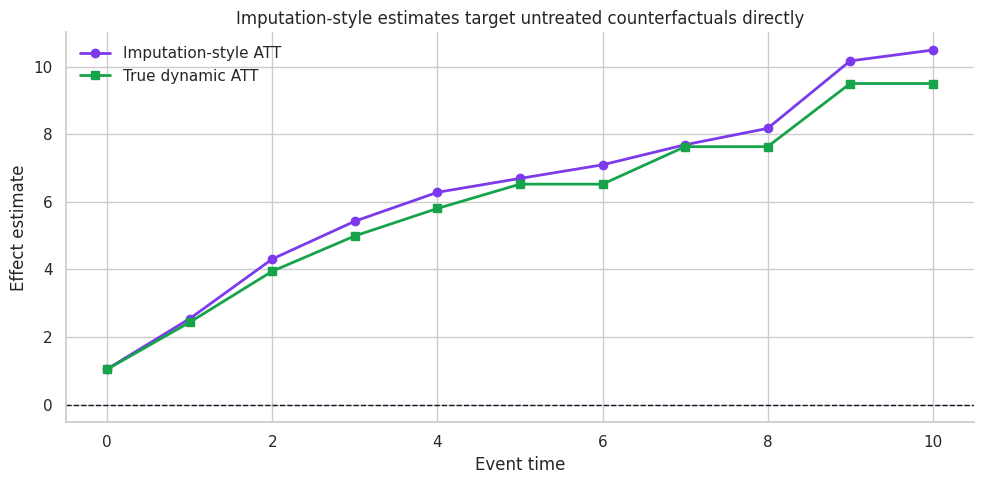

In [19]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
imputation_dynamic = (
    df_imputed[df_imputed["treated"].eq(1)]
    .groupby("event_time", observed=True)
    .agg(
        imputation_att=("tau_hat_imputation", "mean"),
        true_att=("true_effect", "mean"),
        treated_observations=("market_id", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(
    imputation_dynamic["event_time"],
    imputation_dynamic["imputation_att"],
    marker="o",
    linewidth=2,
    color="#7c3aed",
    label="Imputation-style ATT",
)
ax.plot(
    imputation_dynamic["event_time"],
    imputation_dynamic["true_att"],
    marker="s",
    linewidth=2,
    color="#16a34a",
    label="True dynamic ATT",
)
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Imputation-style estimates target untreated counterfactuals directly")
ax.set_xlabel("Event time")
ax.set_ylabel("Effect estimate")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The imputation-style estimator asks a different computational question from TWFE. Instead of asking one regression coefficient to summarize all residualized treatment variation, it builds a model for untreated outcomes using untreated observations only. Then it compares observed treated outcomes with predicted untreated counterfactuals.

This is often closer to how industry stakeholders think: "What would these markets have done if the workflow had not launched?"


## 9. Comparing Estimators

Now put the estimators together. Under staggered timing and heterogeneous dynamic effects, the estimand must be explicit.


In [20]:
# Build the summary table used to connect the calculation back to the design question.
estimator_comparison = pd.DataFrame(
    {
        "Estimator": [
            "True ATT over treated observations",
            "Static TWFE",
            "Clean group-time ATT",
            "Imputation-style ATT",
        ],
        "Estimate": [
            true_att,
            twfe_model.params["treated"],
            clean_static_att,
            imputation_static_att,
        ],
        "Interpretation": [
            "Oracle benchmark in the simulation",
            "One coefficient from residualized treatment variation",
            "Aggregates ATT(g,t) using not-yet-treated or never-treated controls",
            "Observed treated outcomes minus imputed untreated outcomes",
        ],
    }
)
smart_display(estimator_comparison)


,Estimator,Estimate,Interpretation
0,True ATT over treated observations,5.083,Oracle benchmark in the simulation
1,Static TWFE,2.957,One coefficient from residualized treatment va...
2,Clean group-time ATT,5.080,"Aggregates ATT(g,t) using not-yet-treated or n..."
3,Imputation-style ATT,5.414,Observed treated outcomes minus imputed untrea...


In Comparing Estimators, judge the output by the design claim that stands in for randomization. The design feature, not the regression command, carries the identification claim.

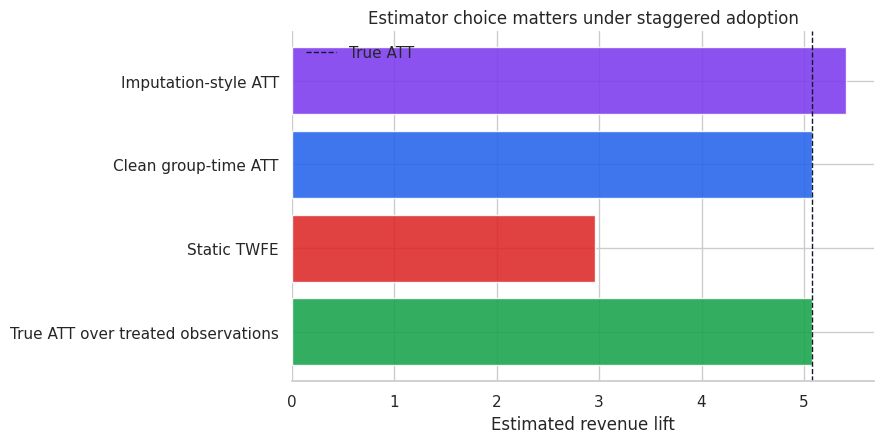

In [21]:
# Build the Comparing Estimators plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.6))
plot_df = estimator_comparison.copy()
colors = ["#16a34a", "#dc2626", "#2563eb", "#7c3aed"]
ax.barh(plot_df["Estimator"], plot_df["Estimate"], color=colors, alpha=0.88)
ax.axvline(true_att, color="#111827", linestyle="--", linewidth=1, label="True ATT")
ax.set_title("Estimator choice matters under staggered adoption")
ax.set_xlabel("Estimated revenue lift")
ax.legend(frameon=False)
sns.despine(ax=ax, left=True)
plt.tight_layout()


The static TWFE estimate is the outlier because it is not targeting the same clean average. The group-time and imputation-style approaches are much closer to the true average in this simulation.


## 10. A Simple Comparison Audit

A practical way to explain staggered-adoption problems is to list which comparisons are clean and which are risky.

Clean comparisons use not-yet-treated or never-treated units as controls. Risky comparisons use already treated units as controls. The latter can subtract treatment effects from the control group and distort the estimate.


In [22]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def comparison_status(row):
    """Label whether a comparison is clean, already treated, or not yet treated.

    Args:
        row: Row from a summary table used to build text or status output.

    Returns:
        str: Comparison status label.
    """
    if row["treated"] == 0:
        if not np.isfinite(row["cohort"]):
            return "never treated control"
        return "not yet treated control"
    return "already treated"

comparison_snapshot = df[df["month"].isin([5, 7, 9, 11])].copy()
comparison_snapshot["status"] = comparison_snapshot.apply(comparison_status, axis=1)
comparison_audit = (
    comparison_snapshot.groupby(["month", "cohort_label", "status"], observed=True)
    .agg(markets=("market_id", "nunique"), avg_true_effect=("true_effect", "mean"))
    .reset_index()
)
comparison_audit.head(20)

,month,cohort_label,status,markets,avg_true_effect
0,5,10,not yet treated control,40,0.000
1,5,4,already treated,49,3.990
2,5,6,not yet treated control,64,0.000
3,5,8,not yet treated control,54,0.000
4,5,Never,never treated control,53,0.000
5,7,10,not yet treated control,40,0.000
6,7,4,already treated,49,8.170
7,7,6,already treated,64,2.604
8,7,8,not yet treated control,54,0.000
9,7,Never,never treated control,53,0.000


In A Simple Comparison Audit, judge the table by the design claim that stands in for randomization. For quasi-experiments, the credibility comes from the rule or timing that creates the comparison.

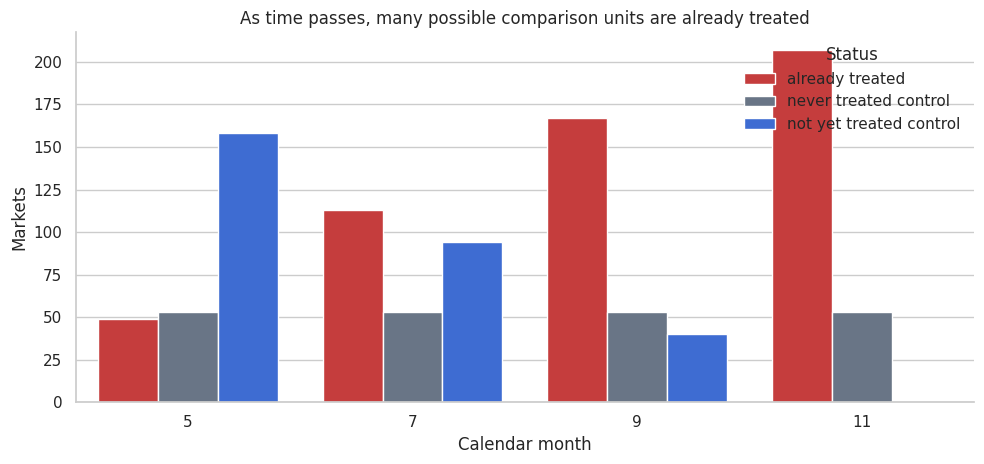

In [23]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(10, 4.8))
status_counts = (
    comparison_snapshot.groupby(["month", "status"], observed=True)["market_id"]
    .nunique()
    .reset_index(name="markets")
)
sns.barplot(
    data=status_counts,
    x="month",
    y="markets",
    hue="status",
    palette={
        "not yet treated control": "#2563eb",
        "never treated control": "#64748b",
        "already treated": "#dc2626",
    },
    ax=ax,
)
ax.set_title("As time passes, many possible comparison units are already treated")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Markets")
ax.legend(title="Status", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


By later months, many markets are already treated. A naive fixed-effects regression can implicitly use those already treated markets in comparisons. A clean group-time design says: for cohort $g$ at time $t$, controls should not yet be treated at $t$ or should never be treated.


## 11. What to Report in a Modern Staggered DiD Analysis

A professional staggered-adoption readout should include:

- A cohort table: how many units adopt in each period and how many never adopt.
- A timing plot: when each cohort becomes treated.
- A statement of the target estimand: overall ATT, cohort-specific ATT, event-time ATT, or decision-window ATT.
- A clear control rule: never-treated only, not-yet-treated, or another justified comparison set.
- A warning if conventional TWFE is reported: explain potential negative weights and already-treated controls.
- A dynamic plot from a robust approach: group-time, interaction-weighted, imputation, or another modern estimator.
- Pre-treatment diagnostics based on clean comparisons, including conventional TWFE event-study leads when appropriate.
- Sensitivity to adoption cohorts: does the result depend entirely on early or late adopters?


In [24]:
# Assemble the What to Report in a Modern Staggered DiD Analysis summary table used for interpretation.
cohort_readout = (
    df.drop_duplicates("market_id")
    .assign(adoption_month=lambda x: x["cohort_label"])
    .groupby("adoption_month", observed=True)
    .agg(
        markets=("market_id", "nunique"),
        avg_readiness=("baseline_ai_readiness", "mean"),
    )
    .reindex(["4", "6", "8", "10", "Never"])
    .reset_index()
)
smart_display(cohort_readout)


,adoption_month,markets,avg_readiness
0,4,49,0.814
1,6,64,0.558
2,8,54,0.452
3,10,40,-0.214
4,Never,53,-0.031


In What to Report in a Modern Staggered DiD Analysis, the table is also evidence about the trend assumption. A convincing pre-period pattern is what lets the post-period gap carry causal weight.

In [25]:
# Build the summary table used to connect the calculation back to the design question.
readout = pd.DataFrame(
    {
        "Item": [
            "Rollout structure",
            "Risk in conventional TWFE",
            "Static TWFE estimate",
            "Clean group-time estimate",
            "Imputation-style estimate",
            "Preferred decision number",
            "Interpretation",
        ],
        "Example entry": [
            "Markets adopt in months 4, 6, 8, and 10; some never adopt",
            f"{(cell_weights['weight'] < 0).sum()} treated cohort-period cells receive negative TWFE weight",
            f"{twfe_model.params['treated']:.2f}",
            f"{clean_static_att:.2f}",
            f"{imputation_static_att:.2f}",
            "Use clean group-time or imputation estimate, not static TWFE",
            "The AI workflow has positive effects that ramp up and are largest in high-readiness early cohorts",
        ],
    }
)
smart_display(readout)


,Item,Example entry
0,Rollout structure,"Markets adopt in months 4, 6, 8, and 10; some ..."
1,Risk in conventional TWFE,5 treated cohort-period cells receive negative...
2,Static TWFE estimate,2.96
3,Clean group-time estimate,5.08
4,Imputation-style estimate,5.41
5,Preferred decision number,"Use clean group-time or imputation estimate, n..."
6,Interpretation,The AI workflow has positive effects that ramp...


## 12. Checklist for Industry Projects

Use this checklist before relying on a staggered DiD estimate:

1. **Map adoption timing.** Count units by first treatment period and never-treated status.
2. **Audit why timing varies.** Readiness-based timing can create effect heterogeneity even if parallel trends are plausible.
3. **Define the estimand.** Decide whether the decision needs an overall, cohort-specific, event-time, or steady-state effect.
4. **Avoid already-treated controls.** Use not-yet-treated or never-treated controls when estimating group-time effects.
5. **Be cautious with static TWFE.** It may be useful as a diagnostic, while the main causal estimate should be tied to an explicit estimand.
6. **Be cautious with TWFE event-study leads.** Apparent pre-trends can be artifacts under heterogeneous effects.
7. **Report dynamics.** Staggered rollouts often have ramp-up, learning, fatigue, or saturation.
8. **Separate design from software.** The important question is not which package produced the coefficient, but which comparisons identify it.


## Key Takeaways

- Staggered adoption means units start treatment at different times.
- Standard TWFE can compare newly treated units to already treated units.
- With heterogeneous or dynamic effects, those comparisons can create negative weights and misleading averages.
- Conventional TWFE event-study leads can be contaminated even when true anticipation effects are zero.
- Group-time ATT estimators use cleaner comparisons: treated cohort versus not-yet-treated or never-treated controls.
- Imputation-style estimators model untreated potential outcomes using untreated observations, then impute counterfactuals for treated observations.
- In applied work, report the adoption cohorts, target estimand, control rule, and dynamic effect path.


## References

Borusyak, K., Jaravel, X., & Spiess, J. (2024). Revisiting event-study designs: Robust and efficient estimation. *The Review of Economic Studies, 91*(6), 3253-3285. https://doi.org/10.1093/restud/rdae007

Callaway, B. (2022). Difference-in-differences for policy evaluation. *arXiv*. https://doi.org/10.48550/arXiv.2203.15646

Callaway, B., & Sant'Anna, P. H. C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics, 225*(2), 200-230. https://doi.org/10.1016/j.jeconom.2020.12.001

De Chaisemartin, C., & D'Haultfoeuille, X. (2020). Two-way fixed effects estimators with heterogeneous treatment effects. *American Economic Review, 110*(9), 2964-2996. https://doi.org/10.1257/aer.20181169

Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics, 225*(2), 254-277. https://doi.org/10.1016/j.jeconom.2021.03.014

Sun, L., & Abraham, S. (2021). Estimating dynamic treatment effects in event studies with heterogeneous treatment effects. *Journal of Econometrics, 225*(2), 175-199. https://doi.org/10.1016/j.jeconom.2020.09.006
